<a href="https://colab.research.google.com/github/patcon/valency-anndata/blob/main/docs/notebooks/recipe-polis2-statements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
%pip install --quiet \
  "git+https://github.com/patcon/polis@package-commentgraph#subdirectory=delphi/umap_narrative/polismath_commentgraph" \
  "git+https://github.com/patcon/valency-anndata@main"

In [2]:
import valency_anndata as val

In [11]:
adata = val.datasets.polis.load("https://pol.is/report/r7wehfsmutrwndviddnii")

Data was gathered using the Polis software (see: https://compdemocracy.org/polis
and https://github.com/compdemocracy/polis) and is sub-licensed under CC BY 4.0
with Attribution to The Computational Democracy Project.
The data and more information about how the data was collected can be found at
the following link: https://pol.is/report/r7wehfsmutrwndviddnii


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

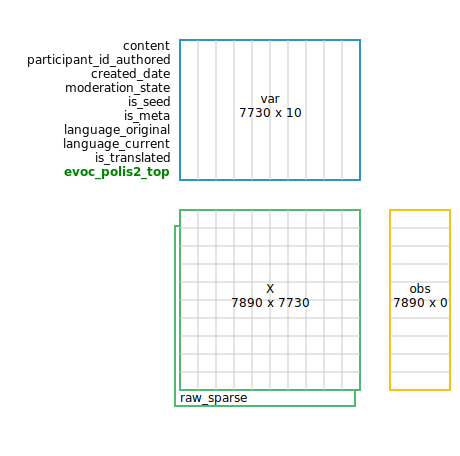

In [12]:
with val.viz.schematic_diagram(diff_from=adata):
    val.tools.recipe_polis2_statements(adata)

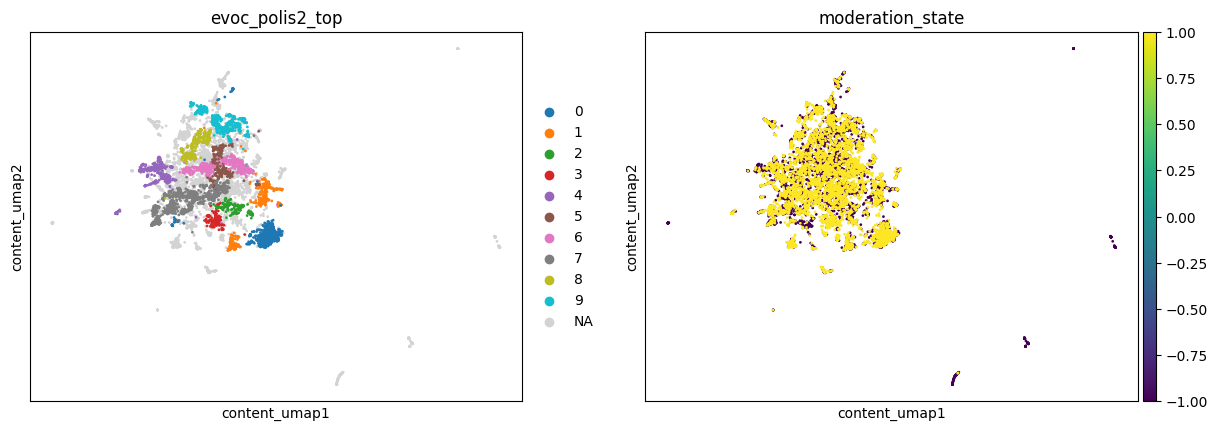

In [13]:
val.viz.embedding(
    # Transpose .var and .obs axes for plotting
    adata.transpose(),
    basis="content_umap",
    color=["evoc_polis2_top", "moderation_state"],
)

In [6]:
%%capture
%pip install datamapplot

<InteractiveFigure width=100% height=500>
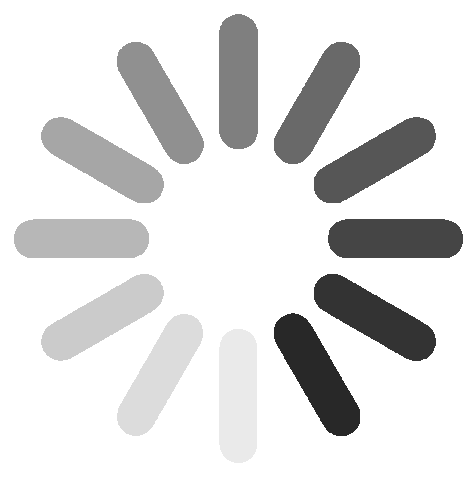

In [39]:
import datamapplot
import numpy as np

label_layers = adata.varm["evoc_polis2"].transpose()
# Humanized cluster labels in layers (not real topics yet)
label_layers_humanized = [
    [f"Zoom{zoom_level}:Group{group_id}" for group_id in row]
    for zoom_level, row in enumerate(reversed(label_layers), start=1)
]

datamapplot.create_interactive_plot(
    adata.varm["content_umap"],
    *label_layers_humanized,
    title="Bowling Green 2050",
    sub_title=f"{adata.shape[1]} statements",
    hover_text=adata.var["content"],
    enable_search=True,
    darkmode=True,
    height=500,
    # Needed because we have so many statements.
    # See: https://github.com/TutteInstitute/datamapplot/pull/67
    palette_theta_range=np.pi / 8,
)